# Train the stacked predictive RNN with a **learned timeconstant** (with actions)

Trains `LearnedTauStackedRNNPredictor` on rollouts driven by a `RandomShiftPolicy`.
Each layer's recurrence is conditioned on the per-timestep action, and its
timeconstant is **learned per unit at every step** (`tau -> 0` means slow,
persistent dynamics):

    tau(t)   = sigmoid(tau_encoder(h(t) + noise, input(t), action(t)))
    h(t+1)   = (1 - tau(t)) * h(t) + tanh(tau(t) * encoder(h(t) + noise, input(t), action(t)))

An L1 regularizer on the mean tau (weight `TAU_REG_COEFF`, optionally per-layer)
pushes the model toward slow dynamics unless faster updating helps prediction.

- **Layer 0** next-step predicts the (action-driven) stimulus.
- **Each higher layer** auto-encodes the layer below it, conditioned on the same action.

Set the task with `TASK`, the depth with `HIDDEN_DIMS`, the policy with
`ACTION_PROBABILITY`, and the tau regularizer with `TAU_REG_COEFF`.


## Config

In [1]:
# --- task choice ---
TASK = 'drift'   # 'binary_noise' | 'drift' | 'gaussian_process' | 'bifurcate'

# --- task / data ---
VECTOR_LENGTH = 12
SEQ_LEN       = 80
NUM_TRAIN_SEQ = 256
NUM_EVAL_SEQ  = 1
SEED          = 0

# --- policy / actions ---
ACTION_PROBABILITY  = 0.2    # RandomShiftPolicy: prob of a left/right shift each step
USE_ACTION_FEEDBACK = True   # append one-hot of the executed action to the next input

# --- model ---
HIDDEN_DIMS = [64, 64, 64]   # one entry per layer -> 3 layers by default
INITIALIZER_HIDDEN_SIZES = [64, 64]   # hidden sizes of the state-init MLPs
NOISE_STD   = 0.1
DECODER_SCALE_INPUT  = 2.0   # layer-0 decoder saturates here (covers [0, 1] stimuli)
DECODER_SCALE_LATENT = 3.0   # higher-layer decoders saturate here (cover latents ~ +/-1)
TAU_REG_COEFF = 0.05         # L1 weight on mean tau (scalar, or a per-layer list)

# --- training ---
NUM_EPOCHS    = 200
BATCH_SIZE    = 64
LEARNING_RATE = 3e-3

In [2]:
import sys
sys.path.insert(0, '..')

import numpy as np
import torch
import matplotlib.pyplot as plt

from tasks import (BinaryNoiseTask, DriftTask, GaussianProcessTask, BifurcateTask,
                   RandomShiftPolicy, rollout)
from tasks.actions import ACTION_DIM, NONE, LEFT, RIGHT, one_hot, feedback
from models import LearnedTauStackedRNNPredictor

torch.manual_seed(SEED)

## Build data from policy rollouts

Each example is an independent rollout of the chosen task under the policy. The
model input is the observation, optionally augmented with action feedback; the
actions are one-hot encoded for the recurrence.


In [3]:
def make_task():
    if TASK == 'binary_noise':
        return BinaryNoiseTask(vector_length=VECTOR_LENGTH, prob=0.3, resample_prob=0.1)
    if TASK == 'drift':
        return DriftTask(vector_length=VECTOR_LENGTH, prob=0.3)
    if TASK == 'gaussian_process':
        return GaussianProcessTask(vector_length=VECTOR_LENGTH,
                                   spatial_temperature=3.0, temporal_temperature=5.0)
    if TASK == 'bifurcate':
        return BifurcateTask(vector_length=VECTOR_LENGTH)
    raise ValueError(f'unknown TASK: {TASK}')


def make_dataset(num_seq, base_seed):
    policy = RandomShiftPolicy(action_probability=ACTION_PROBABILITY)
    rollouts = [rollout(make_task(), policy, SEQ_LEN, seed=base_seed + i) for i in range(num_seq)]
    obs = np.stack([o for o, _ in rollouts])
    acts = np.stack([a for _, a in rollouts])
    return obs, acts


def build_tensors(obs, acts):
    codes = np.stack([one_hot(a) for a in acts])          # (N, T, ACTION_DIM)
    x = obs
    if USE_ACTION_FEEDBACK:
        fb = np.stack([feedback(a) for a in acts])        # (N, T, ACTION_DIM)
        x = np.concatenate([obs, fb], axis=-1)
    return (torch.tensor(x, dtype=torch.float32),
            torch.tensor(codes, dtype=torch.float32))


train_obs, train_acts = make_dataset(NUM_TRAIN_SEQ, base_seed=1000)
eval_obs,  eval_acts  = make_dataset(NUM_EVAL_SEQ,  base_seed=9000)

train_x, train_A = build_tensors(train_obs, train_acts)
eval_x,  eval_A  = build_tensors(eval_obs,  eval_acts)

INPUT_DIM = VECTOR_LENGTH + (ACTION_DIM if USE_ACTION_FEEDBACK else 0)
print('train_x', tuple(train_x.shape), 'train_A', tuple(train_A.shape), 'INPUT_DIM', INPUT_DIM)

train_x (256, 80, 14) train_A (256, 80, 2) INPUT_DIM 14


## Build the model

In [4]:
decoder_scale = [DECODER_SCALE_INPUT] + [DECODER_SCALE_LATENT] * (len(HIDDEN_DIMS) - 1)

model = LearnedTauStackedRNNPredictor(
    input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS, action_dim=ACTION_DIM,
    initializer_hidden_sizes=INITIALIZER_HIDDEN_SIZES, noise_std=NOISE_STD,
    decoder_scale=decoder_scale, tau_reg_coeff=TAU_REG_COEFF)
NUM_LAYERS = model.num_layers
print(f'{NUM_LAYERS} layers, hidden dims {HIDDEN_DIMS}, action_dim {ACTION_DIM}, '
      f'feedback={USE_ACTION_FEEDBACK}, tau_reg_coeff={model.tau_reg_coeffs}')

3 layers, hidden dims [64, 64, 64], action_dim 2, feedback=True, tau_reg_coeff=[0.05, 0.05, 0.05]


## Train

The total loss is the sum of each layer's L1 next-step loss plus its mean-tau L1
regularizer. Per-layer gradients stay separate (higher layers consume detached
latents). We track the per-layer L1 and the per-layer mean tau over training.


In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

l1_hist   = [[] for _ in range(NUM_LAYERS)]
tau_hist  = [[] for _ in range(NUM_LAYERS)]
model.train()
for epoch in range(NUM_EPOCHS):
    perm = torch.randperm(train_x.shape[0])
    ep_l1  = np.zeros(NUM_LAYERS)
    ep_tau = np.zeros(NUM_LAYERS)
    num_batches = 0
    for start in range(0, train_x.shape[0], BATCH_SIZE):
        idx = perm[start:start + BATCH_SIZE]
        optimizer.zero_grad()
        res = model.compute_losses(train_x[idx], train_A[idx])
        res['total'].backward()
        optimizer.step()
        ep_l1  += np.array([t.item() for t in res['l1']])
        ep_tau += np.array([float(t.mean()) for t in res['taus']])
        num_batches += 1
    ep_l1 /= num_batches
    ep_tau /= num_batches
    for i in range(NUM_LAYERS):
        l1_hist[i].append(ep_l1[i])
        tau_hist[i].append(ep_tau[i])
    if (epoch + 1) % 50 == 0 or epoch == 0:
        l1s  = '  '.join(f'L{i}={ep_l1[i]:.4f}' for i in range(NUM_LAYERS))
        taus = '  '.join(f'tau{i}={ep_tau[i]:.3f}' for i in range(NUM_LAYERS))
        print(f'epoch {epoch + 1:4d}  {l1s}   |   {taus}')

/var/folders/_h/nj1cpgkx7yl40q0b31fq3swr0000gn/T/ipykernel_61529/4195932567.py:18: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  ep_tau += np.array([float(t.mean()) for t in res['taus']])


epoch    1  L0=0.3796  L1=0.1512  L2=0.1255   |   tau0=0.491  tau1=0.489  tau2=0.492
epoch   50  L0=0.0992  L1=0.0450  L2=0.0098   |   tau0=0.324  tau1=0.018  tau2=0.046
epoch  100  L0=0.0967  L1=0.0373  L2=0.0082   |   tau0=0.232  tau1=0.010  tau2=0.042
epoch  150  L0=0.0929  L1=0.0322  L2=0.0057   |   tau0=0.198  tau1=0.008  tau2=0.032
epoch  200  L0=0.0892  L1=0.0297  L2=0.0037   |   tau0=0.181  tau1=0.006  tau2=0.023


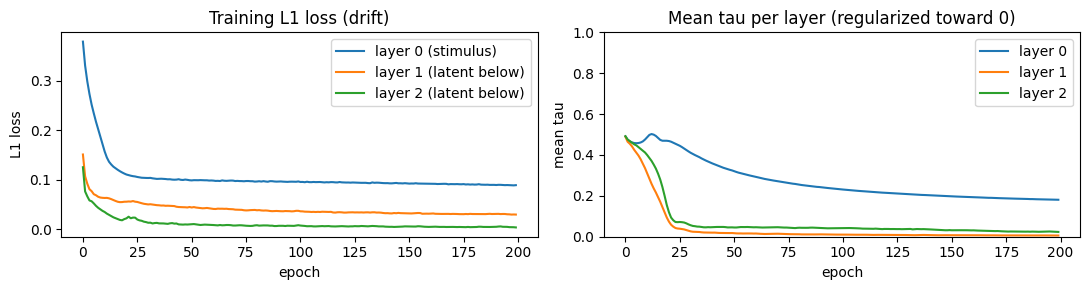

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
for i in range(NUM_LAYERS):
    label = 'layer 0 (stimulus)' if i == 0 else f'layer {i} (latent below)'
    axes[0].plot(l1_hist[i], label=label)
    axes[1].plot(tau_hist[i], label=f'layer {i}')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('L1 loss')
axes[0].set_title(f'Training L1 loss ({TASK})'); axes[0].legend()
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('mean tau')
axes[1].set_title('Mean tau per layer (regularized toward 0)'); axes[1].set_ylim(0, 1); axes[1].legend()
plt.tight_layout(); plt.show()

## Evaluate and visualize

`eval()` mode disables the latent noise. Predictions are aligned so
`prediction[t]` sits against its target `input[t+1]`.


In [7]:
model.eval()
with torch.no_grad():
    out = model(eval_x, eval_A)

inputs = [out['inputs'][i][0].numpy() for i in range(NUM_LAYERS)]
preds  = [out['predictions'][i][0].numpy() for i in range(NUM_LAYERS)]
hidden = [out['hidden'][i][0].numpy() for i in range(NUM_LAYERS)]
taus   = [out['taus'][i][0].numpy() for i in range(NUM_LAYERS)]
acts_eval = eval_acts[0]

stim_pred   = preds[0][:-1, :VECTOR_LENGTH]
stim_target = inputs[0][1:, :VECTOR_LENGTH]
print(f'layer 0 eval mean L1 (stimulus dims): {np.abs(stim_pred - stim_target).mean():.4f}')
if USE_ACTION_FEEDBACK:
    act_pred   = preds[0][:-1, VECTOR_LENGTH:]
    act_target = inputs[0][1:, VECTOR_LENGTH:]
    print(f'layer 0 eval mean L1 (action dims):   {np.abs(act_pred - act_target).mean():.4f}')
for i in range(1, NUM_LAYERS):
    v = float(np.abs(preds[i][:-1] - inputs[i][1:]).mean())
    print(f'layer {i} eval mean L1 (layer-{i-1} latent): {v:.4f}')
print('mean tau per layer:', [round(float(t.mean()), 3) for t in taus])

layer 0 eval mean L1 (stimulus dims): 0.0700
layer 0 eval mean L1 (action dims):   0.0080
layer 1 eval mean L1 (layer-0 latent): 0.0226
layer 2 eval mean L1 (layer-1 latent): 0.0037
mean tau per layer: [0.185, 0.006, 0.023]


In [8]:
# Plotting helper: heatmap panels with an aligned "action executed" strip on top.
# A dedicated colorbar column keeps every panel (and the strip) at the same
# x-extent, so timesteps line up vertically across all rows. When the input
# carries action-feedback dims, `feature_split` draws a line marking them off.
_ACTION_RGB = {NONE: (1, 1, 1), LEFT: (0.20, 0.40, 0.85), RIGHT: (0.85, 0.25, 0.20)}

def plot_panels_with_actions(panels, strip_actions, panel_height=2.6, feature_split=None):
    n = len(panels)
    T = panels[0]['data'].shape[0]
    strip_actions = np.asarray(strip_actions)
    fig = plt.figure(figsize=(10, 1.0 + panel_height * n))
    gs = fig.add_gridspec(n + 1, 2, width_ratios=[40, 1],
                          height_ratios=[1] + [8] * n, hspace=0.55, wspace=0.04)

    ax_strip = fig.add_subplot(gs[0, 0])
    strip_rgb = np.array([_ACTION_RGB[int(a)] for a in strip_actions])[None, :, :]
    ax_strip.imshow(strip_rgb, aspect='auto', interpolation='nearest', extent=[-0.5, T - 0.5, 0, 1])
    ax_strip.set_yticks([])
    ax_strip.set_title('action executed  (blue = left, red = right, blank = none)')

    axes = []
    for k, p in enumerate(panels):
        ax = fig.add_subplot(gs[k + 1, 0], sharex=ax_strip)
        C = p['data'].shape[1]
        im = ax.imshow(p['data'].T, aspect='auto', cmap=p['cmap'],
                       vmin=p.get('vmin'), vmax=p.get('vmax'), interpolation='nearest')
        ax.set_title(p['title'])
        ax.set_ylabel(p.get('ylabel', 'element'))
        if feature_split is not None and feature_split < C:
            ax.axhline(feature_split - 0.5, color='w', lw=1.6, ls='--')
            ax.axhline(feature_split - 0.5, color='k', lw=0.6, ls='--')
            ax.text(1.004, (feature_split + (C - feature_split) / 2 - 0.5) / C, 'action',
                    transform=ax.get_yaxis_transform(), rotation=90,
                    va='center', ha='left', fontsize=7, color='0.35')
        fig.colorbar(im, cax=fig.add_subplot(gs[k + 1, 1]))
        axes.append(ax)

    for ax in axes[:-1]:
        plt.setp(ax.get_xticklabels(), visible=False)
    axes[-1].set_xlabel('timestep')
    plt.show()

### Layer 0: predictions vs. ground-truth input

The input vector is `[stimulus | action code]` when `USE_ACTION_FEEDBACK` is on:
the bottom `ACTION_DIM` rows (below the dashed line) hold the one-hot of the
action that produced that column. The action strip: blue = left, red = right.


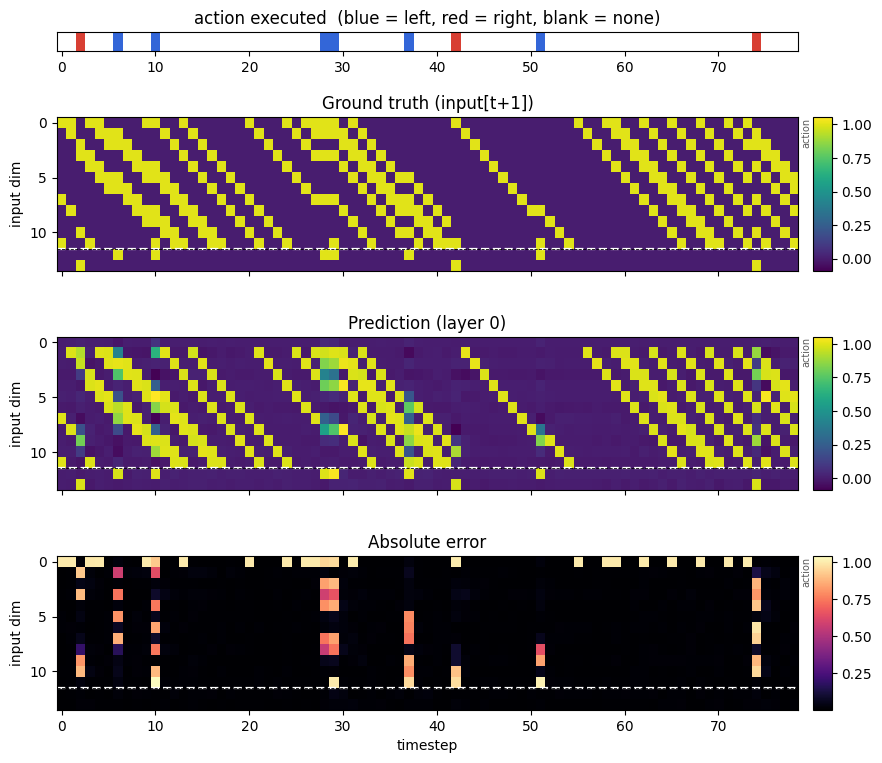

In [9]:
target = inputs[0][1:]
pred_aligned = preds[0][:-1]
T = target.shape[0]
vmin = min(target.min(), pred_aligned.min())
vmax = max(target.max(), pred_aligned.max())
split = VECTOR_LENGTH if USE_ACTION_FEEDBACK else None

plot_panels_with_actions(
    panels=[
        {'title': 'Ground truth (input[t+1])', 'data': target,
         'cmap': 'viridis', 'vmin': vmin, 'vmax': vmax, 'ylabel': 'input dim'},
        {'title': 'Prediction (layer 0)', 'data': pred_aligned,
         'cmap': 'viridis', 'vmin': vmin, 'vmax': vmax, 'ylabel': 'input dim'},
        {'title': 'Absolute error', 'data': np.abs(pred_aligned - target),
         'cmap': 'magma', 'ylabel': 'input dim'},
    ],
    strip_actions=acts_eval[:T],
    feature_split=split,
)

### Latent-space activity for every layer

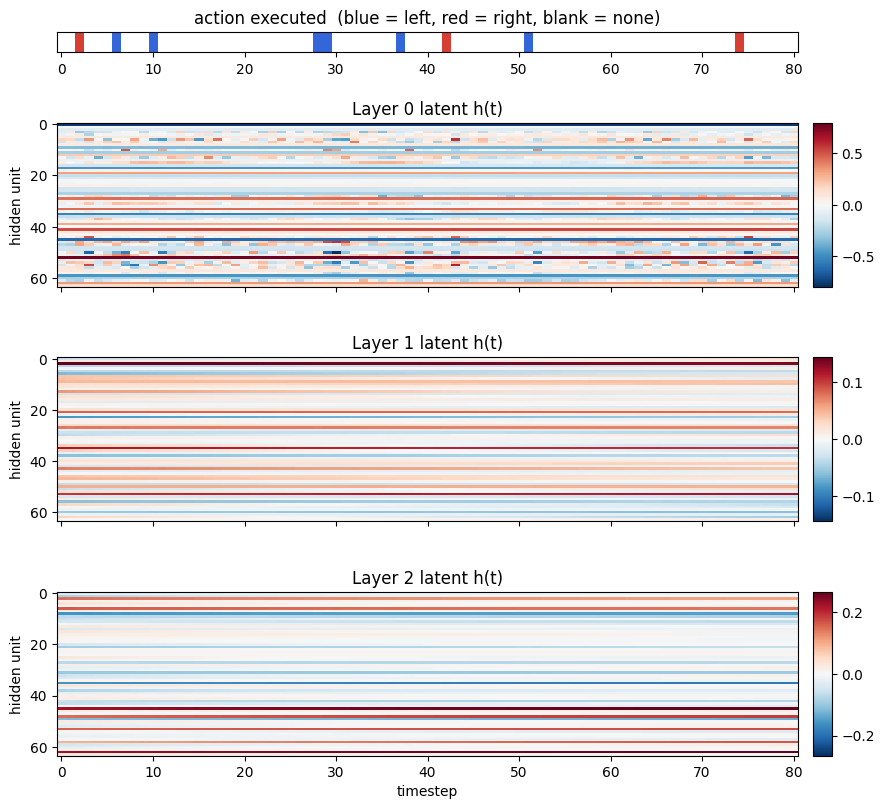

In [10]:
S = hidden[0].shape[0]
strip_latent = np.append(acts_eval[:S - 1], NONE)
panels = []
for i in range(NUM_LAYERS):
    scale = np.abs(hidden[i]).max()
    panels.append({'title': f'Layer {i} latent h(t)', 'data': hidden[i], 'cmap': 'RdBu_r',
                   'vmin': -scale, 'vmax': scale, 'ylabel': 'hidden unit'})
plot_panels_with_actions(panels, strip_latent, panel_height=2.8)

### Learned timeconstant tau for every layer

`tau[t]` is the per-unit timeconstant used at step `t` (in [0, 1]; small = slow).
Units that stay dark hold their state for a long time; bright units update fast.


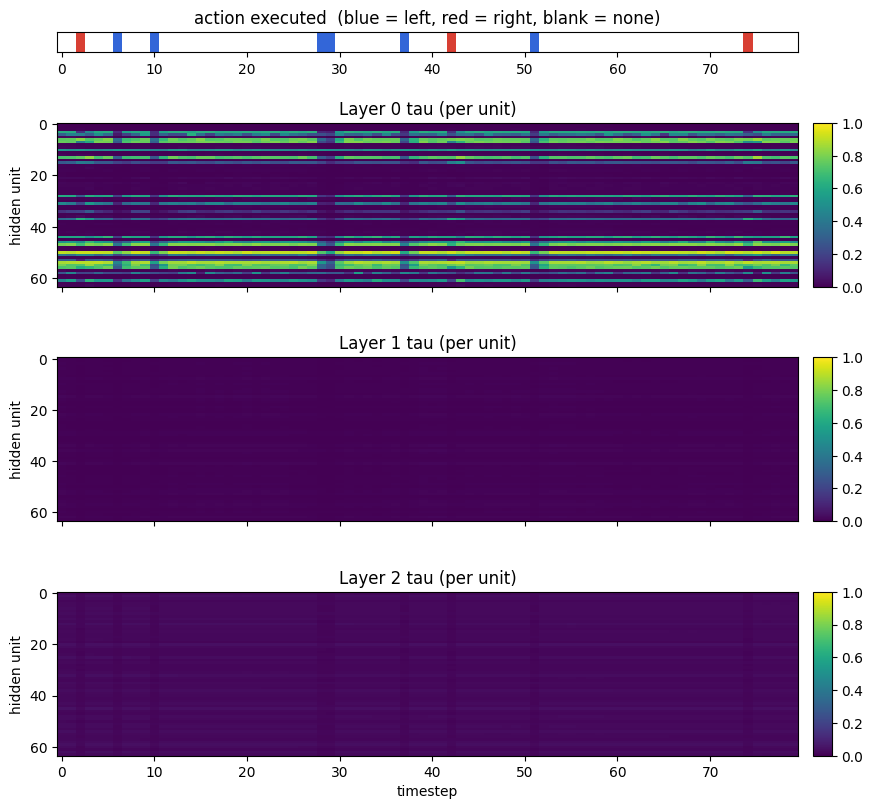

In [11]:
Ttau = taus[0].shape[0]
panels = [{'title': f'Layer {i} tau (per unit)', 'data': taus[i], 'cmap': 'viridis',
           'vmin': 0, 'vmax': 1, 'ylabel': 'hidden unit'} for i in range(NUM_LAYERS)]
plot_panels_with_actions(panels, acts_eval[:Ttau], panel_height=2.8)

### Higher layers: predicting the latent trajectory below

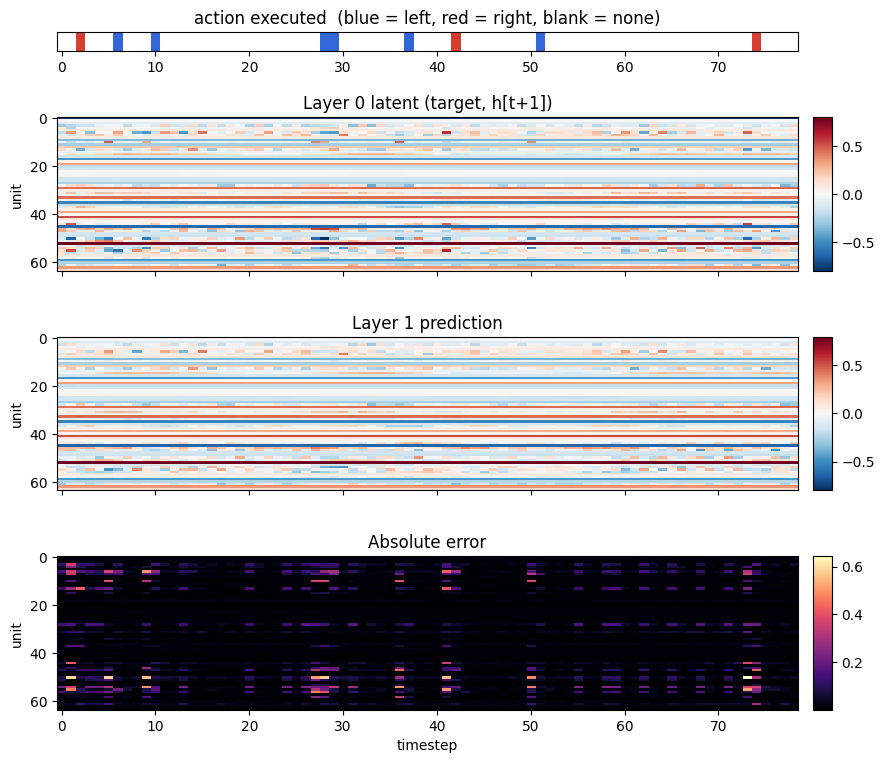

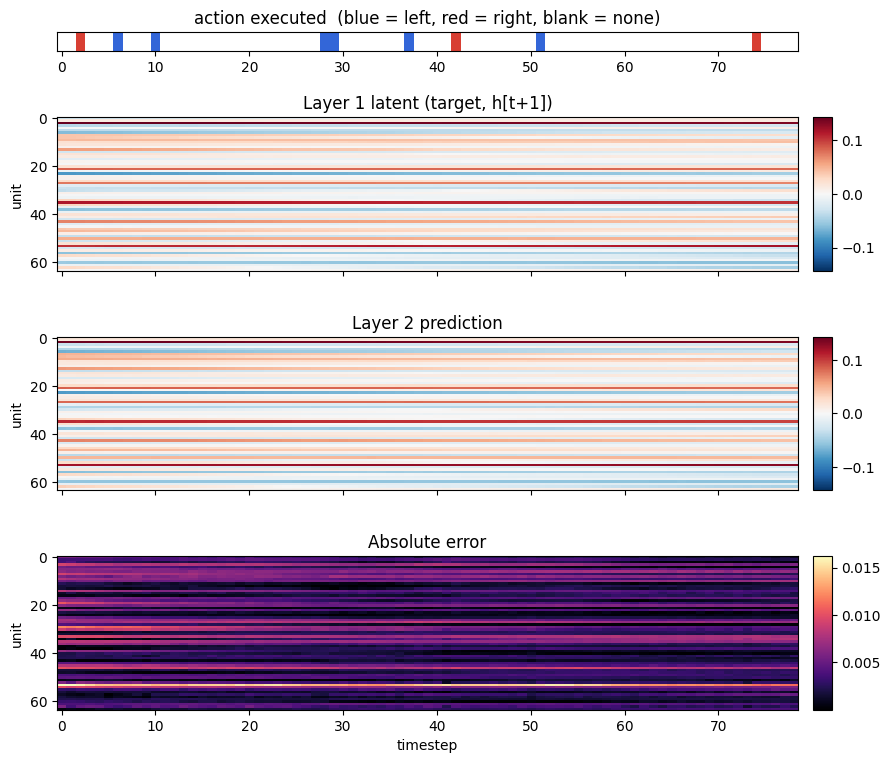

In [12]:
for i in range(1, NUM_LAYERS):
    tgt = inputs[i][1:]
    prd = preds[i][:-1]
    Ti = tgt.shape[0]
    scale = np.abs(np.concatenate([tgt, prd])).max()
    plot_panels_with_actions(
        panels=[
            {'title': f'Layer {i-1} latent (target, h[t+1])', 'data': tgt,
             'cmap': 'RdBu_r', 'vmin': -scale, 'vmax': scale, 'ylabel': 'unit'},
            {'title': f'Layer {i} prediction', 'data': prd,
             'cmap': 'RdBu_r', 'vmin': -scale, 'vmax': scale, 'ylabel': 'unit'},
            {'title': 'Absolute error', 'data': np.abs(prd - tgt),
             'cmap': 'magma', 'ylabel': 'unit'},
        ],
        strip_actions=acts_eval[:Ti],
    )